In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import statsmodels.api as sm
import statsmodels.formula.api as smf
from patsy import dmatrices
from stargazer.stargazer import Stargazer
import seaborn as sns
import matplotlib.pyplot as plt

import warnings
warnings.filterwarnings(action='once')

## Data Cleaning & Imports

In [2]:
data = pd.read_csv("data/cafc.csv")
french=['Type de plainte reçue', 
        'Pays',
        'Type de plainte reçue',
        'Pays',
        'Catégories thématiques sur la fraude et la cybercriminalité',
        'Méthode de sollicitation',
        'Genre',
        'Langue de correspondance',
        'Province/État',
        'Type de plainte']

col_rename = {
"Numéro d'identification / Number ID":"ID",
'Date Received / Date reçue':"Date",
"Fraud and Cybercrime Thematic Categories":"Category",
"Victim Age Range / Tranche d'âge des victimes":"Age",
"Number of Victims / Nombre de victimes":"Victim Count",
"Dollar Loss /pertes financières":"Dollar Loss",
"Province/State":"Province"
}

# Change Items to English & correct value types
data = data.drop(columns = french)
data.rename(columns = col_rename, inplace=True)
data = data[data["Dollar Loss"] != "$0.00"]
data["Dollar Loss"] = data["Dollar Loss"].replace('[\$,]', '', regex=True).astype(float)
data = data.replace(["Prefer not to say","Other/unknown","Not Specified","Not Available", "'Not Available / non disponible"], np.nan)
data['Age'] = data['Age'].str.strip().str.strip("'\"")

# Drop certain unwanted variables
age_drop = [
"Deceased / Décédé",
"Business / Entreprise",
]
data = data[~data["Age"].isin(age_drop)]


# Filter to Canada Only
data['Date'] = pd.to_datetime(data['Date'])
data = data[data["Country"]=="Canada"]

data.head()

<>:27: SyntaxWarning: invalid escape sequence '\$'
<>:27: SyntaxWarning: invalid escape sequence '\$'
/tmp/ipykernel_21071/3771434006.py:27: SyntaxWarning: invalid escape sequence '\$'
  data["Dollar Loss"] = data["Dollar Loss"].replace('[\$,]', '', regex=True).astype(float)


,ID,Date,Complaint Received Type,Country,Province,Category,Solicitation Method,Gender,Language of Correspondence,Age,Complaint Type,Victim Count,Dollar Loss
5,350313,2025-09-29,Phone,Canada,Alberta,Investments,Internet,Male,English,70 - 79,Victim,1,20000.00
9,350317,2025-09-29,Phone,Canada,Quebec,Service,Internet,NaN,French,20 - 29,Victim,1,596.67
14,350322,2025-09-29,Phone,Canada,Quebec,Service,Internet-social network,Male,French,50 - 59,Victim,1,599.01
15,350323,2025-09-29,Phone,Canada,Quebec,Spear Phishing,Email,NaN,French,NaN,Victim,1,4649.05
19,350327,2025-09-29,Phone,Canada,Quebec,Spear Phishing,Email,NaN,French,NaN,Victim,1,50294.82


## Data Exploration & Adjustments

If we have fewer than around 100 observations we'll be removing them. Same for the "Unknown" and "Other" Categories

In [3]:
category_drops = ["Unknown","Other","Vacation","Charity / Donation","Psychics","Unauthorized Charge","Incomplete","Credit Card","Collection Agency","Health","Directory","Survey","Telecom Fraud","Spoofing","Fraudulent Cheque"]
data = data[~data["Category"].isin(category_drops)]

solicit_drop = ["Mail","Television","Video Call","Print","Radio"]
data = data[~data["Solicitation Method"].isin(solicit_drop)]

In [4]:
data["Dollar Loss"].describe().apply(lambda x: format(x, 'f'))

count       56642.000000
mean        35042.899000
std        199178.358905
min             0.010000
25%           432.520000
50%          2500.000000
75%         15700.000000
max      18599009.700000
Name: Dollar Loss, dtype: object

In [5]:
data.shape[0]

56642

In [6]:
data.columns

Index(['ID', 'Date', 'Complaint Received Type', 'Country', 'Province',
       'Category', 'Solicitation Method', 'Gender',
       'Language of Correspondence', 'Age', 'Complaint Type', 'Victim Count',
       'Dollar Loss'],
      dtype='object')

# Plots

### Dollars Loss over time

/tmp/ipykernel_21071/2759054652.py:8: FutureWarning: 'Q' is deprecated and will be removed in a future version, please use 'QE' instead.
  monthly = filtered.groupby([pd.Grouper(key='Date', freq='Q'), 'Method'])['Dollar Loss'].median().reset_index()


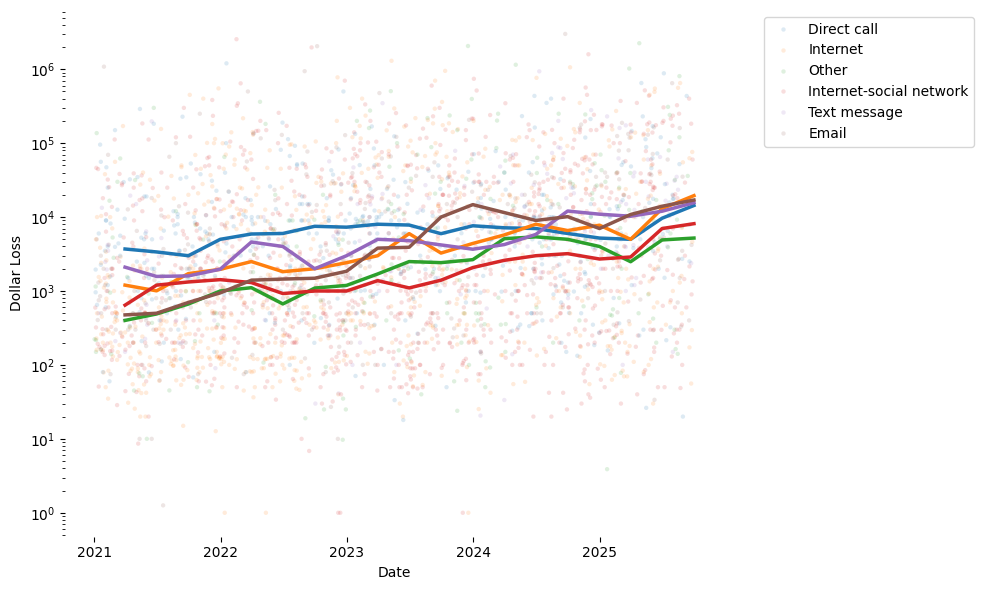

In [7]:
filtered = data[data['Dollar Loss'] >= 1].copy()
top_methods = data['Solicitation Method'].value_counts().head(5).index
filtered['Method'] = filtered['Solicitation Method'].where(
    filtered['Solicitation Method'].isin(top_methods), 'Other'
)

# full dataset for smooth trend lines
monthly = filtered.groupby([pd.Grouper(key='Date', freq='Q'), 'Method'])['Dollar Loss'].median().reset_index()

# sample just for scatter
subset = filtered.sample(3000, random_state=1)

f, ax = plt.subplots(figsize=(10, 6))
sns.scatterplot(x="Date", y="Dollar Loss",
                hue="Method", alpha=0.15, s=10,
                linewidth=0, data=subset, ax=ax)
sns.lineplot(x='Date', y='Dollar Loss', hue='Method',
             data=monthly, ax=ax, legend=False, linewidth=2.5)

ax.set_yscale('log')
ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
sns.despine(f, left=True, bottom=True)
plt.tight_layout()

### Provinces

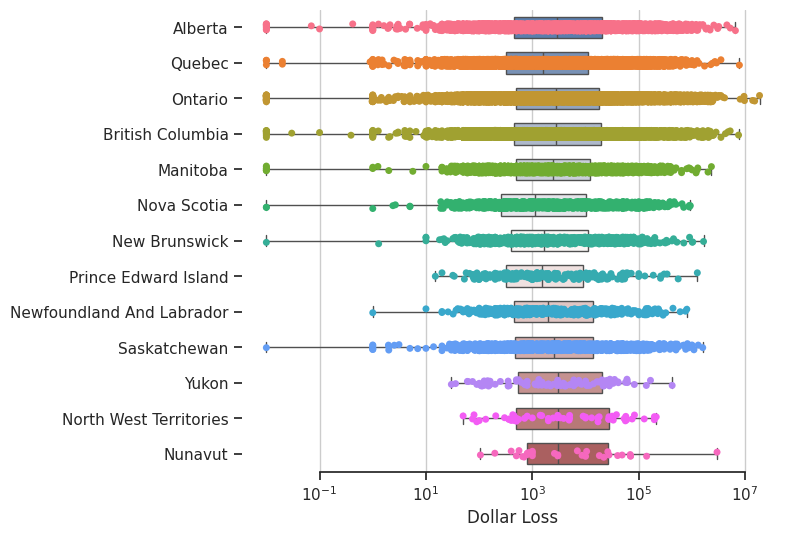

In [8]:
sns.set_theme(style="ticks")
f, ax = plt.subplots(figsize=(7,6))
ax.set_xscale("log")
sns.boxplot(
    data, x="Dollar Loss", y="Province", hue="Province",
    whis=[0,100], width=.6,palette="vlag"
)

sns.stripplot(data,x="Dollar Loss", y="Province", hue="Province")

plt.legend([],[], frameon=False)
ax.xaxis.grid(True)
ax.set(ylabel="")
sns.despine(trim=True,left=True)

### Category

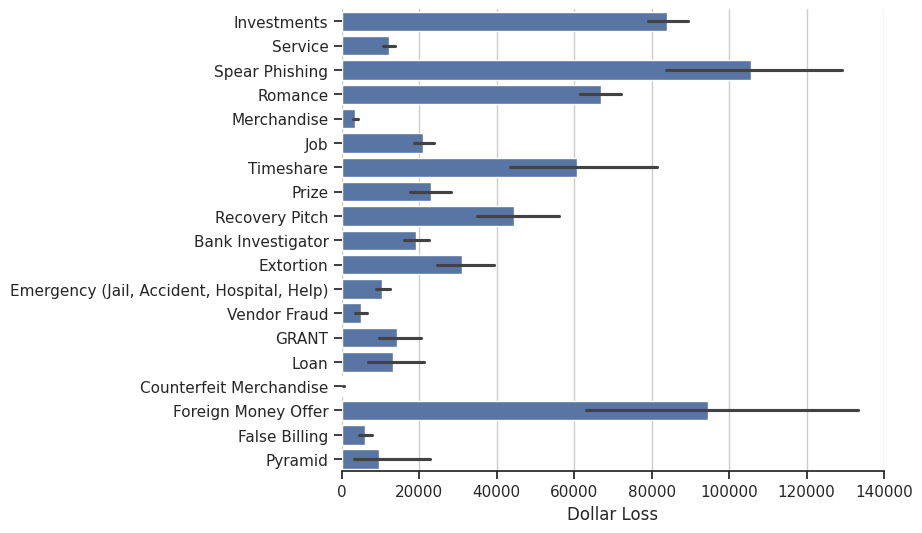

In [9]:
sns.set_theme(style="ticks")
f, ax = plt.subplots(figsize=(7,6))
sns.barplot(
    data, x="Dollar Loss", y="Category", label = "Total", color="b")

plt.legend([],[], frameon=False)
ax.xaxis.grid(True)
ax.set(ylabel="")
sns.despine(trim=True,left=True)

## Solicitation Method

In [10]:
data["Solicitation Method"].value_counts()

Solicitation Method
Internet-social network    19527
Internet                   15477
Direct call                 9403
Email                       5182
Text message                2829
Door to door/in person       895
Name: count, dtype: int64

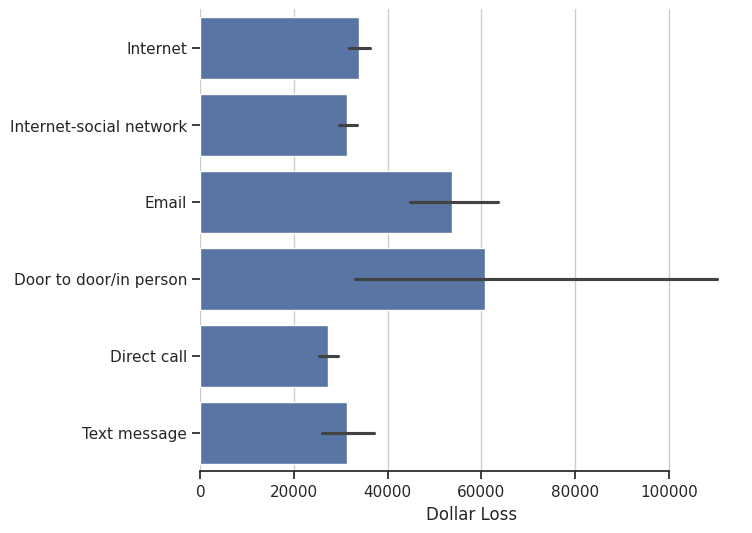

In [11]:
sns.set_theme(style="ticks")
f, ax = plt.subplots(figsize=(7,6))
sns.barplot(
    data, x="Dollar Loss", y="Solicitation Method", label = "Total", color="b")

plt.legend([],[], frameon=False)
ax.xaxis.grid(True)
ax.set(ylabel="")
sns.despine(trim=True,left=True)

From the overview provinces are all relatively close together in dollar loss amounts meanwhile the category used and the socitation method vary quite a bit in Dollar Loss. Previously when I analyzed the 2024/25 dataset I saw a similar occurence that I attributed to the personability of the fraud techniques and the amount of effort used.

## Linear Models

### Age & Gender Model

Previously I treated the ages as categories, but this time around i'm trying out using the midpoint

In [12]:
midpoints = {
    '0 - 9': 5, '10 - 19': 15, '20 - 29': 25, '30 - 39': 35,
    '40 - 49': 45, '50 - 59': 55, '60 - 69': 65, '70 - 79': 75,
    '80 - 89': 85, '90 - 99': 95, '100 +': 100
}
data['AgeMid'] = data['Age'].map(midpoints)

In [13]:
age_linear = smf.ols('Q("Dollar Loss") ~ Gender + AgeMid', data=data).fit()
age_quad = smf.ols('Q("Dollar Loss") ~ Gender + AgeMid + I(AgeMid**2)', data=data).fit()
age_linear_int = smf.ols('Q("Dollar Loss") ~ Gender + AgeMid + Gender:AgeMid', data=data).fit()
age_quad_int = smf.ols('Q("Dollar Loss") ~ Gender + AgeMid + I(AgeMid**2) +Gender:I(AgeMid**2)', data=data).fit()
Stargazer([age_linear, age_quad, age_linear_int, age_quad_int])

### Category Model

In [14]:
high_loss = ['Investments', 'Romance', 'Spear Phishing', 'Foreign Money Offer']
mid_loss = ['Extortion', 'Recovery Pitch', 'Timeshare']

data['FraudGroup'] = data['Category'].apply(
    lambda x: 'High' if x in high_loss else ('Mid' if x in mid_loss else 'Low')
)

cat_age = smf.ols('Q("Dollar Loss") ~ Category + Age', data=data).fit()
cat_gender = smf.ols('Q("Dollar Loss") ~ Category + Gender', data=data).fit()
cat_age_gender = smf.ols('Q("Dollar Loss") ~ Category + Category:Age', data=data).fit()

cat_model = smf.ols('Q("Dollar Loss") ~ Gender + AgeMid + I(AgeMid**2) + C(Category)', data=data).fit()
stargazer = Stargazer([cat_model])
stargazer


### Solicitation Method Model